# Trialing One At A Time Sensitivity Analysis to the OGGM

We will now apply OAT Sensitivity Analysis to our scalar mass balance calibration technique to see which parameters are most sensitive. This does not include SAFE directly but follows a similar technique to that from the Hydrological example of SAFE's section on OAT Sensitivity Analysis.

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.stats as st

import oggm
from oggm import cfg, utils, workflow
from oggm.sandbox.edu import run_constant_climate_with_bias
from oggm.core.massbalance import mb_calibration_from_scalar_mb, apparent_mb_from_any_mb
from oggm.core import massbalance
from oggm.utils._funcs import rmsd
from oggm import tasks

# Install python package for interactive visualisation and import required functions:
!pip install -q ipywidgets
from ipywidgets import interact, FloatRangeSlider, IntRangeSlider

# Install SAFE package and import required functions
!pip install SAFEpython

import safepython

import xarray as xr
import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
import safepython.RSA_thres as RSA_tr # Module that implements RSA
import safepython.plot_functions as pf # Module to visualize the results
from safepython.model_execution import model_execution # Module to execute the model
from safepython.sampling import AAT_sampling, AAT_sampling_extend # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping
from safepython.util import empiricalcdf
from safepython.util import RMSE

In [2]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2026-01-07 15:29:35: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-01-07 15:29:35: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-01-07 15:29:35: oggm.cfg: Multiprocessing: using all available processors (N=22)


2026-01-07 15:29:36: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-01-07 15:29:36: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-01-07 15:29:36: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [3]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2026-01-07 15:29:39: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-01-07 15:29:39: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


# 1 - One-at-a-time Sensitivity Analysis

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

We cannot compare the runoff specifically to observed runoff since the OGGM does not contain this data.

In [ ]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF
print(mbdf['ANNUAL_BALANCE'].mean())
def oat_oggm_runner(sample_row):
    
    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']
    
    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)

    print('prcp_f', cfg.PARAMS['prcp_fac'])
    
    # # Calibrating the model
    # mb_calibration_from_scalar_mb(gdir_hef, 
    #                                      ref_mb=mbdf['ANNUAL_BALANCE'].mean(),
    #                                      ref_mb_years=mbdf.index.tolist(),
    #                                      overwrite_gdir=True,
    #                                      overwrite_observations = True,
    #                                      calibrate_param1='prcp_fac',
    #                                      calibrate_param2='melt_f',
    #                                      calibrate_param3='temp_bias',
    #                                      melt_f = melt_f,
    #                                      prcp_fac=prcp_fac,
    #                                      temp_bias=temp_bias)
    
    mbmod = massbalance.MonthlyTIModel(gdir_hef)
    fls = gdir_hef.read_pickle('inversion_flowlines')
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
    std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
    rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))
    
    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    # Run this again with the calibrated parameters
    file_id = '_sim'

    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                    run_task=tasks.run_from_climate_data,  # running from observed climate data
                    ys=2000,  # Period which we will average and constantly repeat
                    init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                    init_model_yr=2000, # Start from spinup year 2000
                    store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                    output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
    # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()

    # Plot the runoff again for the calibrated melt_f parameter
    sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
    df_annual = ds[sel_vars].to_dataframe()
    
    # Calculating runoff
    df_runoff = df_annual[runoff_vars] * 1e-9

    return df_runoff, mean_diff, std_diff, rmsd_


-1122.75


We will now plot our results, the parameter values can be changed one-at-a-time via a toggle on the graph below.

Note that not every combination of parameters will work here - some will lead to model crashes.

In [ ]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series

def oat_function(melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Note that not every combination of parameters will work here - some will lead to model crashes.
    param = np.array([melt_f, prcp_fac, temp_bias])
    df_runoff_melt_f, _, _, _ = oat_oggm_runner(param)
    plt.figure(figsize=[15,3])
    runoff = df_runoff_melt_f.sum(axis=1) # Calculate total runoff from all components

    plt.plot(runoff, 'k')
    plt.xlabel('Year')
    plt.ylabel('Runoff (km$^3$ yr$^{-1}$)')
    plt.title('Runoff time series for melt_f={:.1f}, prcp_fac={:.1f}, temp_bias={:.1f}°C'.format(melt_f, prcp_fac, temp_bias))
    plt.show()

interact(oat_function,
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));

interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

Here we can vary the toggles and see how the behaviour of the timeseries changes with differing values of our parameters.

Firstly by varying the melt_f parameter between 1.5 and 17, at 1.5 the runoff peaks at around 15 km $^3$ yr $^{-1}$, when increasing the toggle to have melt_f = 17, the peak runoff increases to around 81 km $^3 $ yr $^{-1}$. The shape of the graph here remains roughly the same with the exception of the end of the time series around 2017 becoming flatter.

Repeating this now with fixing the other parameters at their default value and changing the values of the prcp_fac, starting at 0.1 km $^3 $ yr $^{-1}$ the peak runoff is around 23, when increasing the prcp_fac = 10 the peak runoff remains around the same. This is not showing much of a sensitivity.

Finally repeating for the temp_bias parameter, starting at temp_bias = -15, the peak runoff sits at around 25 km $^3 $ yr $^{-1}$, then when increasing the temp_bias up to 15, the peak runoff increases up to around 90 km $^3 $ yr $^{-1}$. The change in this parameter also causes more of a change in the shape of our time series as well.

Therefore the sensitvity of both melt_f and temp_bias both seem high in our model, and the sensitivity of the prcp_fac seems low in our model. When considering the difference in the maximum runoffs, prcp_fac does not seem to affect the system at all whereas both melt_f and prcp_fac have roughly the same effect.

This sensitivity is likely due to the way the OGGM calibration works and the ranges of values we have considered in our sensitvity study.

In our runner above we have set all three parameters to be considered in calibration, due to the order in which we have set the calibration, the OGGM will firstly attempt to calibrate the model with prcp_fac, then melt_f and then temp_bias. Therefore the melt_f and temp_bias are only calibrated when the mean mass balance cannot be reached by calibrating just prcp_fac.

The OGGM Scalar calibration technique works in the following way here: We fix the values for prcp_fac, melt_f and temp_bias and start by calibrating prcp_fac. Depending on the values that the melt_f and temp_bias are set to a solution to the prcp_fac will likely be found. If not, prcp_fac is fixed to one of it's boundaries and the next parameter is used to calibrate.

Since this is the case, the prcp_fac toggle has no real effect on the calibration therefore making the sensitivity seem negligible.

Let's alter the order of parameters in our calibration and see if this makes a difference to our OAT sensitivity. We will firstly start by adding the order of calibration to be melt_f calibrated first, then prcp_fac and then temp_bias. Here we would expect the melt_f to appear to have negligible effect on the output of our model.

In [6]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF
print(mbdf['ANNUAL_BALANCE'].mean())
def oat_oggm_runner(sample_row):
    
    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']
    
    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)

    print('prcp_f', cfg.PARAMS['prcp_fac'])
    
    # # Calibrating the model
    # mb_calibration_from_scalar_mb(gdir_hef, 
    #                                      ref_mb=mbdf['ANNUAL_BALANCE'].mean(),
    #                                      ref_mb_years=mbdf.index.tolist(),
    #                                      overwrite_gdir=True,
    #                                      overwrite_observations = True,
    #                                      calibrate_param1='melt_f',
    #                                      calibrate_param2='prcp_fac',
    #                                      calibrate_param3='temp_bias',
    #                                      melt_f = melt_f,
    #                                      prcp_fac=prcp_fac,
    #                                      temp_bias=temp_bias)
    
    mbmod = massbalance.MonthlyTIModel(gdir_hef)
    fls = gdir_hef.read_pickle('inversion_flowlines')
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
    std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
    rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))
    
    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    # Run this again with the calibrated parameters
    file_id = '_sim'

    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                    run_task=tasks.run_from_climate_data,  # running from observed climate data
                    ys=2000,  # Period which we will average and constantly repeat
                    init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                    init_model_yr=2000, # Start from spinup year 2000
                    store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                    output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
    # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()

    # Plot the runoff again for the calibrated melt_f parameter
    sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
    df_annual = ds[sel_vars].to_dataframe()
    
    print(gdir_hef.read_json('mb_calib'))
    # Calculating runoff
    df_runoff = df_annual[runoff_vars] * 1e-9

    return df_runoff, mean_diff, std_diff, rmsd_


-1122.75


In [ ]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series

def oat_function(melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Note that not every combination of parameters will work here - some will lead to model crashes.
    param = np.array([melt_f, prcp_fac, temp_bias])
    df_runoff_melt_f, _, _, _ = oat_oggm_runner(param)
    plt.figure(figsize=[15,3])
    runoff = df_runoff_melt_f.sum(axis=1) # Calculate total runoff from all components

    plt.plot(runoff, 'k')
    plt.xlabel('Year')
    plt.ylabel('Runoff (km$^3$ yr$^{-1}$)')
    plt.title('Runoff time series for melt_f={:.1f}, prcp_fac={:.1f}, temp_bias={:.1f}°C'.format(melt_f, prcp_fac, temp_bias))
    plt.show()

interact(oat_function,
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));

interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

Let's repeat this again with temp_bias as the parameter we are calibrating:

In [8]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF
print(mbdf['ANNUAL_BALANCE'].mean())
def oat_oggm_runner(sample_row):
    
    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']
    
    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)
    
    # # Calibrating the model
    # mb_calibration_from_scalar_mb(gdir_hef, 
    #                                      ref_mb=mbdf['ANNUAL_BALANCE'].mean(),
    #                                      ref_mb_years=mbdf.index.tolist(),
    #                                      overwrite_gdir=True,
    #                                      overwrite_observations = True,
    #                                      calibrate_param1='temp_bias',
    #                                      calibrate_param2='prcp_fac',
    #                                      calibrate_param3='melt_f',
    #                                      melt_f = melt_f,
    #                                      prcp_fac=prcp_fac,
    #                                      temp_bias=temp_bias)
    
    mbmod = massbalance.MonthlyTIModel(gdir_hef)
    fls = gdir_hef.read_pickle('inversion_flowlines')
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
    std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
    rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))
    
    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    # Run this again with the calibrated parameters
    file_id = '_sim'

    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                    run_task=tasks.run_from_climate_data,  # running from observed climate data
                    ys=2000,  # Period which we will average and constantly repeat
                    init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                    init_model_yr=2000, # Start from spinup year 2000
                    store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                    output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
    # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()

    # Plot the runoff again for the calibrated melt_f parameter
    sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
    df_annual = ds[sel_vars].to_dataframe()
    
    print(gdir_hef.read_json('mb_calib'))
    # Calculating runoff
    df_runoff = df_annual[runoff_vars] * 1e-9

    return df_runoff, mean_diff, std_diff, rmsd_


-1122.75


We will just explore the effect of the parameters on the runoff output for now.

In [ ]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series

def oat_function(melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Note that not every combination of parameters will work here - some will lead to model crashes.
    param = np.array([melt_f, prcp_fac, temp_bias])
    df_runoff_melt_f, _, _, _ = oat_oggm_runner(param)
    plt.figure(figsize=[15,3])
    runoff = df_runoff_melt_f.sum(axis=1) # Calculate total runoff from all components

    plt.plot(runoff, 'k')
    plt.xlabel('Year')
    plt.ylabel('Runoff (km$^3$ yr$^{-1}$)')
    plt.title('Runoff time series for melt_f={:.1f}, prcp_fac={:.1f}, temp_bias={:.1f}°C'.format(melt_f, prcp_fac, temp_bias))
    plt.show()

interact(oat_function,
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));



interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

A similar pattern emerges in all of these cases with the sensitivity of each parameter we are calibrating appearing as insignificant to the model, although this may not ouvertly change the outcome when we set the initial values, we know that the choice of parameter we calibrate must be somewhat significant to the model.

Therefore the sensitivity of the model interacts strongly with which order of parameters we are calibrating and it results in the parameter we are calibrating to have the lowest sensitivity. Here it may be intersting to explore the second order interations to see if certain parameters affect the impact of the parameter being calibrated at all.

Although the OAT method is efficient, it provides us with limited information. In the next notebook we will explore higher order sensitivities and some global sensitivity analysis techniques with SAFE.

# 2 - Monte Carlo simulation and qualitative (visual) Global Sensitivity Analysis

In this section we will run Monte Carlo (MC) simulation of the model against a prescribed number of parameter combination, randomly drawn from the feasible parameter ranges. Each model simulation provides a time series of runoff predictions. For each time series we will measure the distance from the observations by means of a synthetic performance metric. Here we have implemented:

In [ ]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

count = []

def oggm_runner(sample_row):

    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']
    
    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)
    
    # # Calibrate the model
    # mb_calibration_from_scalar_mb(gdir_hef, 
    #                                      ref_mb=mbdf['ANNUAL_BALANCE'].mean(),
    #                                      ref_mb_years=mbdf.index.tolist(),
    #                                      overwrite_gdir=True,
    #                                      overwrite_observations = True,
    #                                      calibrate_param1='prcp_fac',
    #                                      calibrate_param2='melt_f',
    #                                      calibrate_param3='temp_bias',
    #                                      melt_f = melt_f,
    #                                      prcp_fac=prcp_fac,
    #                                      temp_bias=temp_bias)
    
    mbmod = massbalance.MonthlyTIModel(gdir_hef)
    fls = gdir_hef.read_pickle('inversion_flowlines')
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
    std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
    rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))

    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    # Run this again with the calibrated parameters
    file_id = '_sim'

    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                    run_task=tasks.run_from_climate_data,  # running from observed climate data
                    ys=2000,  # Period which we will average and constantly repeat
                    init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                    init_model_yr=2000, # Start from spinup year 2000
                    store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                    output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
    # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()

    # Plot the runoff again for the calibrated melt_f parameter
    sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
    df_annual = ds[sel_vars].to_dataframe()
    
    # Calculating runoff
    df_runoff = df_annual[runoff_vars] * 1e-9
    runoff = np.array(df_runoff.sum(axis=1))

    count.append(prcp_fac)

    return runoff, mean_diff, std_diff, rmsd_

# Define input variability space:
X_Labels = ['melt_f', 'prcp_fac', 'temp_bias'] # Name of parameters (used to customize plots) - standard as to what we are currently calibrating with the scalar mb function
M = len(X_Labels) # Number of parameters
distr_fun = st.uniform # Parameter distributions
xmin = [1.5, 0.1, -15] # Parameter ranges (lower bound) - currently as the standard in OGGM
xmax = [17, 10, 15] # Parameter ranges (upper bound) - currently as the standard in OGGM

# Save lower and upper bound in the appropriate format to be passed on to the sampling function:
distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [xmin[i], xmax[i] - xmin[i]]
samp_strat = 'lhs' # sampling strategy (options: 'lhs' = Latin Hypercube sampling,'rsu' = Random uniform sampling)

N = 100 # Number of samples - was 3000 changed to 100
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Perform sampling

# Execute the model against all the samples in 'X':
QQ = model_execution(oggm_runner, X)

# check volume, mean mb and runoff?

2026-01-07 15:30:56: oggm.cfg: PARAMS['melt_f'] changed from `8.087258667010666` to `5.378624175373252`.


2026-01-07 15:30:56: oggm.cfg: PARAMS['prcp_fac'] changed from `3.1540197282424267` to `1.499512223765195`.
2026-01-07 15:30:56: oggm.cfg: PARAMS['temp_bias'] changed from `-14.968561092531122` to `-13.652315015658093`.
2026-01-07 15:30:57: oggm.cfg: PARAMS['melt_f'] changed from `5.378624175373252` to `4.9837059791321865`.
2026-01-07 15:30:57: oggm.cfg: PARAMS['prcp_fac'] changed from `1.499512223765195` to `5.998144633434786`.
2026-01-07 15:30:57: oggm.cfg: PARAMS['temp_bias'] changed from `-13.652315015658093` to `-7.1029825687109795`.
2026-01-07 15:30:58: oggm.cfg: PARAMS['melt_f'] changed from `4.9837059791321865` to `12.497857871879528`.
2026-01-07 15:30:58: oggm.cfg: PARAMS['prcp_fac'] changed from `5.998144633434786` to `0.27356532939794487`.
2026-01-07 15:30:58: oggm.cfg: PARAMS['temp_bias'] changed from `-7.1029825687109795` to `5.891496437425861`.
2026-01-07 15:30:58: oggm.cfg: PARAMS['melt_f'] changed from `12.497857871879528` to `13.309137372713536`.
2026-01-07 15:30:58: o

Now plotting the MC simulations results.

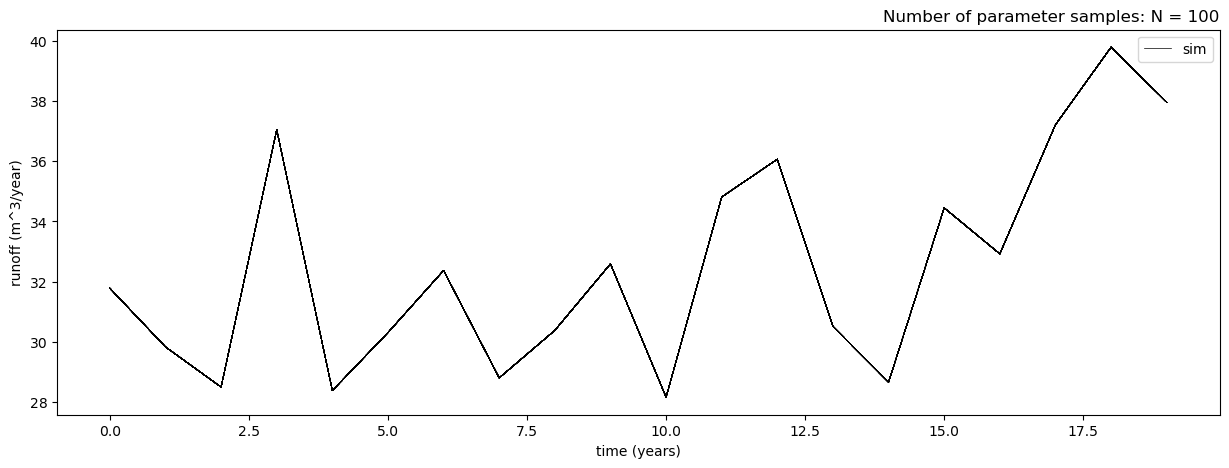

In [14]:
# Plot Monte Carlo (MC) simulations results:
plt.figure(figsize=[15,5])
plt.plot(np.transpose(QQ), 'k', linewidth = 0.5)
plt.ylabel('runoff (m^3/year)'); plt.xlabel('time (years)')
plt.legend(['sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

There appears to be clustering at the extremes: minimum runoff and maximum runoff. As previously discussed, the parameters need to compensate to produce the same MB (our calibration metric).


For example: 
Combinations with higher precipitation factor, will require a higher melt factor → higher runoff.
Combinations with lower precipitation factor, will require a lower melt factor → lower runoff. 

Let's investigate the proportion of how many prcp_fac values are calibrated towards the boundaries.

In [13]:
print(len(list(filter(lambda x: x < 1, count))))

print(len(list(filter(lambda x: x > 9, count))))

print(len(list(filter(lambda x: 1 <= x <= 9, count))))

9
10
82


We do not have observational data for the runoff in the OGGM, we will therefore switch to another method. As the methodology in PAWN requires observational data, which we do not have for the runoff data, we will continue this work in the safe.ipynb notebook.